# Milestone Project 1: Food Vision Big

## Check GPU

Google colab offeres free GPUs, however not all of them are compatible with mixed precision training.

Google Colab offeres:
* K80 (not compatible)
* P100 (not compatible)
* Tesla T4 (compatible)

In [1]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-f4cb0471-3cf4-3a88-76cc-3783fc94a541)


## Get helper function

In past modules, we've created a bunch of helper functions to do small tasks required for our notesbooks.
Rather than rewrite all of these, we can import a script and load them in from there.

In [2]:
# Import series of helper functions for the notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Use TensorFlow datasets to download data

In [3]:
# Get TensorFlow Datasets
import tensorflow_datasets as tfds

C:\Users\Priyesh\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# list all available datasets
datasets_list = tfds.list_builders() # Get all available datasets in TFDS
print("food101" in datasets_list)

True


In [5]:
# Load in the data (takes 5-6 minutes in Google colab)
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True, # data gets returned in tuple format (data, label)
                                             with_info=True)

## Exploring the Food101 data from TensorFlow datasets

In [6]:
# Features of Food1-1 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [7]:
# Get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [16]:
# Take one sample of the train data
train_one_sample = train_data.take(2) # Sample are in format (image_tensor, label)

In [17]:
# what does one sample of our training data look like?
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [18]:
# Output info about our training sample
for image, label in train_one_sample:
    print(f"""
          Image shape: {image.shape}
          Image datatype: {image.dtype}
          Target classfrom Food101 (tensor form): {label}
          Class name (str form): {class_names[label.numpy()]}
          """)


          Image shape: (382, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 52
          Class name (str form): gyoza
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 68
          Class name (str form): onion_rings
          


In [19]:
# What does our image tensor from TFDS's Food101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[239, 231, 212],
        [239, 231, 212],
        [240, 229, 211],
        ...,
        [139, 130, 123],
        [146, 137, 130],
        [151, 142, 135]],

       [[237, 229, 210],
        [238, 230, 211],
        [240, 229, 211],
        ...,
        [136, 127, 118],
        [140, 132, 119],
        [144, 136, 123]],

       [[235, 227, 208],
        [237, 229, 210],
        [241, 230, 212],
        ...,
        [135, 126, 117],
        [138, 130, 117],
        [140, 133, 117]],

       ...,

       [[238, 223, 202],
        [237, 222, 201],
        [236, 221, 200],
        ...,
        [238, 234, 222],
        [239, 235, 223],
        [239, 235, 223]],

       [[239, 224, 203],
        [238, 223, 202],
        [236, 221, 200],
        ...,
        [239, 235, 223],
        [240, 236, 224],
        [240, 236, 224]],

       [[239, 224, 203],
        [237, 222, 201],
        [236, 221, 200],
        ...,
        [240, 236, 22

In [20]:
# min and max values of in our image tensor
import tensorflow as tf
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image from TensorFlow datasets

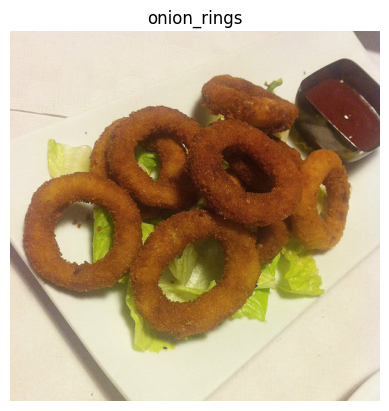

In [21]:
# Plot an image tensor
import matplotlib.pyplot as plt 
plt.imshow(image)
plt.title(class_names[label.numpy()]) # Add title to image to verify the label is associated with the right image 
plt.axis(False);

## Create preprocessing functions for our data

Neural networks perform best when data is in a certain way (e. g. batched, normalized, etc)

However, not all data (including data from TensorFlow datasets) comes like this.

So in order to get it ready for a neural network, you'll often have to write preprocessing functions and map it to your data.

What we know about our data:
* In `uint8` datatype
* Comprised of all different size tensors (different size images)
* Not scaled (the pixel values are between 0 & 255)

What we know models like:
* Data in `float32` dtype (or for mixed precision `float16` and `float32`)
* For batches, TensorFlow likes all of the tensors within a batch to be of the same size.
* Scaled (values between 0 & 1) also called normalized tensors generally perform better

With these points in mind, we've got a few things we can tackle with a preprocessing function.